<center><h1><u>Recherche Opérationnelle</u></h1></center>

## <u>1- Contexte</u>

Nous sommes des contrebandiers intergalactiques, nous devons livrer notre spotchka dans toute la galaxie. Pour cela nous faisons partir plusieurs vaisseau en parallèle, l'objectif minimiser la distance du vaisseau qui fait la plus grande distance.
Cependant, la Spotchka étant illégale nous devons éviter les douanes.

## <u>2- Définitions mathématiques</u>
Avant de se lancer dans l'implémentation d'algorithme nous allons commencé par formaliser le probléme de maniére mathématiques. Cela vas par la suite nous permettre de définir précisement les variables et les contraintes et d'etablir la fonction objectif de nos algorithmes.

<div style="margin-left: 40px;">

### 2.1 Caractéristiques

</div>

L'ensemble des planètes est représenté par :
$$ V = [0;n] $$

La planète 0 étant notre planète de départ.

Sachant que nous sommes dans l'espace nous pouvons rejoindre toutes les planète depuis n'importe quelle autre planète.

On peut donc noter : $$ G = (V, E) $$ où $$ E = {(i,j) / i \neq j, i \in V, j \in V} $$

Chaque arête va posséder :
- Une distance : $ d_{ij} > 0 $
- Un risque : $ r_{ij} > 0 $

Un certain nombre de vaisseaux sont disponibles, on note : $ K \geq 1 $

Sachant que chaque vaisseau doit partir de la planète 0 et y revenir après sa tournée.

<div style="margin-left: 40px;">

### 2.2 Variables

</div>

Variable de décision :

$$ x_{ij}^k = \{0, 1\}$$
Avec 1 si le vaisseau $k$ emprunte l'arête $ij$, 0 sinon.

<div style="margin-left: 40px;">

###  2.3 Fonction objectif

</div>

Notre objectif est de minimiser la distance du vaisseau qui a parcouru la distance maximale.

On peut donc définir la fonction abjectif suivante :
$$ \min(\max_k(\sum_{i=0}^{n} \sum_{j=0}^{n} x_{ij}^k * d_{ij}))

<div style="margin-left: 40px;">

### 2.4 Contraintes

</div>

- Livraison complète : chaque planète doit être visitée une seule fois. Soit 1 seul vaisseau rentre dans la planète et en ressort.
    + Entrée unique :
    $$ \sum_{k=1}^{K} \sum_{j=0}^{n} x_{ij}^k = 1 \quad \forall \: i \neq 0 $$

    + Sortie unique :
    $$ \sum_{k=1}^{K} \sum_{i=0}^{n} x_{ij}^k = 1 \quad \forall \: j \neq 0 $$
    

- Tournées valides : Chaque vaisseau doit partir de la planète 0 et y revenir à la fin.
    + Départ dépôt :
    $$ \sum_{j=0}^{n} x_{0j}^k = 1  \quad \forall \: k $$

    + Retour dépôt :
    $$ \sum_{i=0}^{n} x_{i0}^k = 1  \quad \forall \: k $$
- Risque : chaque vaisseau possède un nombre limité de vies $ R_{max}^k $ 
Pour chaque vaisseau $k$ le risque total des arètes doit être inférieur à son risque max.
$$ \sum_{i=0}^{n} \sum_{j=0}^{n} x_{ij}^k * r_{ij} \leq R_{max}^k $$

## <u>3- Analyse de difficulté</u>
Nous allons désormais passer à l'analyse de la difficulté basée sur la complexité. Cette analyse est importante car elle nous permettra de justifier les choix de métaheuristiques que nous allons mettre en place sur le problème.

Pour démontrer que notre problème est **NP-difficile**, nous utilisons une **réduction polynomiale**. On va montrer que si nous possédions un algorithme capable de résoudre ton problème en un temps raisonnable, nous pourrions résoudre un problème dont nous savons déjà qu'il est **NP-difficile**.

Le candidat idéal pour cette démonstration est le **TSP classique** (Traveling Salesman Problem).

<div style="margin-left: 40px;">

### 3.1 La preuve par restriction

</div>

La manière la plus simple de prouver la complexité d'un problème est de montrer qu'un problème **NP-difficile** connu est un **cas particulier** de notre problème.

<div style="margin-left: 40px;">

### 3.2 Rappel du problème TSP (Problème $P'$)

</div>

Le TSP classique consiste à trouver une tournée unique ($k=1$) visitant tous les sommets une seule fois et minimisant la distance totale. Nous savons que le **TSP** est **NP-difficile**.

<div style="margin-left: 40px;">

### 3.3 Construction de l'instance (La Réduction)

</div>

Supposons que nous avons une instance quelconque du **TSP** : un graphe $G = (V, E)$ avec des poids $c_{ij}$ sur les arêtes. Pour transformer cela en une instance de notre problème, nous fixons les paramètres de la manière suivante :

* **Nombre de véhicules :** On pose $k = 1$.
* **Contrainte de vie :** On pose $v_{ij} = 0$ pour toutes les arêtes du graphe (les arêtes ne font perdre aucune vie).
* **Objectif :** Minimiser la longueur de la tournée la plus longue.


<div style="margin-left: 40px;">

### 3.4 Analyse

</div>

Dans cette configuration spécifique :
1.  Puisqu'il n'y a qu'un seul véhicule ($k=1$),et que chaque sommet doit être visité exactement une fois : La solution recherchée est obligatoirement un **cycle hamiltonien**. Minimiser $Z$ revient alors à trouver, parmi tous les cycles hamiltoniens possibles, celui qui a la somme des poids la plus faible. C'est la définition exacte du **TSP**...

2.  Puisque le coût en vies $v_{ij}$ est nul partout, notre contrainte des "3 vies" est toujours satisfaite (on perd 0 vie, ce qui est inférieur à 3). Elle n'influence donc pas la recherche de la solution.

L'instance du problème se comporte alors exactement comme une instance du **TSP classique**. 

<div style="margin-left: 40px;">

### 3.5 Conclusion de la réduction

</div>

Si nous avions un algorithme polynomial pour résoudre notre problème, nous pourrions résoudre n'importe quel **TSP** en temps polynomial en utilisant la transformation ci-dessus. 

Comme le **TSP** est **NP-difficile**, notre problème est **au moins aussi difficile** que lui. On dit alors qu'il est **NP-difficile**.

<div style="margin-left: 40px;">

### 3.6 Résumé

</div
>
Notre problème combine trois sources de complexité distinctes :

* **La composante Partitionnement (NP-difficile) :** Même sans notion de distance, répartir $n$ sommets entre $k$ véhicules pour équilibrer la charge (le Min-Max) est une variante du *Multiprocessor Scheduling* ou du *Bin Packing*.
* **La composante Hamiltonienne (NP-difficile) :** Trouver l'ordre de passage optimal dans chaque groupe de sommets reste un TSP.
* **La composante Sac à Dos (NP-difficile) :** La contrainte de ressources (les 3 vies) ajoute une dimension de type *Knapsack*. Sur chaque chemin, nous devons vérifier que nous ne dépassons pas une capacité (ici, 2 vies perdues max).

## <u>4 - Implémentation d'algorithme  </u>

Maintenant que nous avons démontré que notre probléme est np-difficile, nous savons  qu'il n'existe probablement pas d'algorithme exact capable de résoudre toutes les instances en temps polynomial.
Elle ne vont pas fonctionner car :
- Les algorithmes exacts (comme la programmation dynamique) ont une complexité exponentielle en fonction du nombre de planètes (n) et de vaisseaux (K). Par exemple :
    + Pour le TSP sous-jacent, la complexité est (O(n!)), ce qui devient impraticable dès (n > 20).
    + Notre problème combine TSP (ordonnancement des tournées), partitionnement (répartition des planètes entre vaisseaux) et sac à dos (contraintes de risque), amplifiant la difficulté.

Donc de cette analyse en découle l'utilisation des méta-heuristiques qui vont être les seules approches viable pour obtenir un résultant de qualité dans un temps raisonnables :
- Elles vont explorer l'espace de solutions de maniére heuristique.
- Elles ne garantissent pas l'optimalité globale, mais vont nous permettre de bon optimum local.
- Elle ne vont pas prendre 2 jours à s'executer.

<div style="margin-left: 40px;">

### 4.1 ACO (Optimisation par Colonies de Fourmis)

</div
> 

Nous allons essayer d'expliquer simplement le fonctionnement de l'algorithme.Il faut imaginé une colonie de fourmis qui cherche de la nourriture : au début, elles partent dans toutes les directions au hasard. Lorsqu’une fourmi trouve une miette de sucre, elle rentre au nid en déposant sur le sol une trace odorante, la phéromone. Si le chemin est court, la fourmi fait plus d'allers-retours, ce qui renforce l'odeur très rapidement. À l'inverse, sur un chemin long, l'odeur a le temps de s'évaporer. Les autres fourmis, attirées par la trace la plus forte, finissent par toutes choisir le chemin le plus efficace. En informatique, l'ACO vas donc copie ce comportement.

Donc notre cas ACO vas être trés intéressant car :
- structure TSP / multi-tournées : ACO construit des routes étape par étape, ce qui correspond à la recherche de tournées pour des vaisseaux.
- objectif min-max : on cherche à équilibrer plusieurs tournées, pas seulement une distance totale. ACO peut explorer plusieurs solutions en parallèle  et renforcer les arcs qui participent à de bonnes tournées.
- contraintes de risque : dans notre implémentation on filtre les arcs non faisables, donc les fourmis restent dans l’espace des solutions valides et apprennent sur des chemins compatibles avec le budget de vies.


====== SOLUTION TROUVÉE ======
Vaisseau 1: [0, 11, 5, 2, 7, 0] | Distance=129 | Vie=8/15
Vaisseau 2: [0, 1, 10, 4, 9, 0] | Distance=116 | Vie=11/15
Vaisseau 3: [0, 6, 3, 8, 0] | Distance=142 | Vie=13/15

Objectif minimax (max distance) = 142


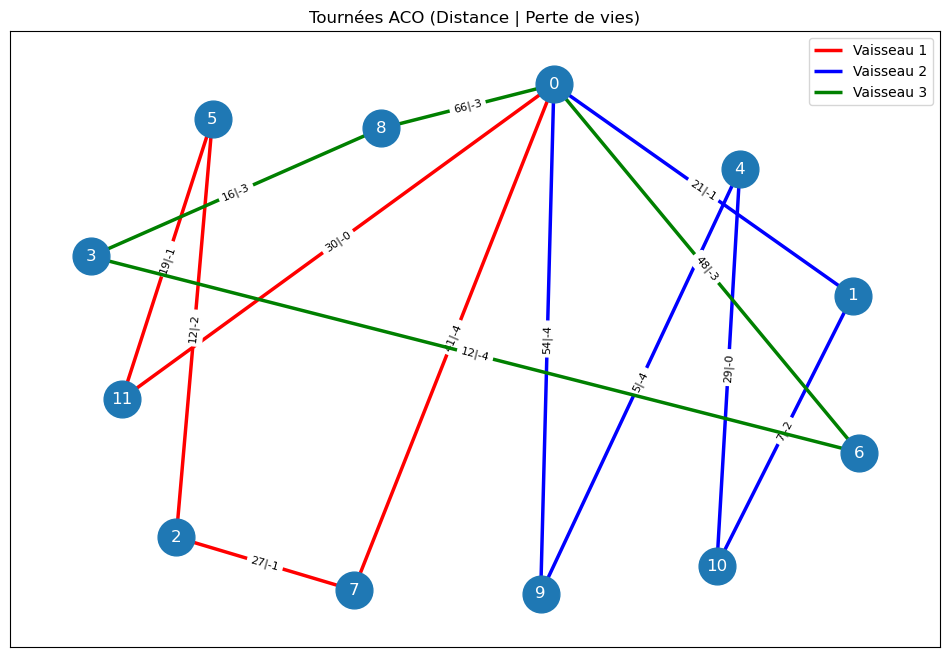

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx

# =======================
# MATRICE DISTANCE
# =======================
D = np.array([
    [0, 21, 57, 59, 50, 49, 48, 41, 66, 54, 25, 30],
    [21, 0, 71, 49, 35, 61, 41, 59, 59, 40, 7, 42],
    [57, 71, 0, 70, 78, 12, 60, 27, 63, 79, 70, 29],
    [59, 49, 70, 0, 21, 58, 12, 76, 16, 18, 43, 52],
    [50, 35, 78, 21, 0, 66, 21, 78, 37, 5, 29, 54],
    [49, 61, 12, 58, 66, 0, 48, 28, 53, 67, 60, 19],
    [48, 41, 60, 12, 21, 48, 0, 65, 20, 21, 35, 41],
    [41, 59, 27, 76, 78, 28, 65, 0, 74, 80, 61, 25],
    [66, 59, 63, 16, 37, 53, 20, 74, 0, 34, 53, 52],
    [54, 40, 79, 18, 5, 67, 21, 80, 34, 0, 34, 56],
    [25, 7, 70, 43, 29, 60, 35, 61, 53, 34, 0, 42],
    [30, 42, 29, 52, 54, 19, 41, 25, 52, 56, 42, 0]
])

n = D.shape[0]

# =======================
# MATRICE PERTE DE VIES ALEATOIRE (0 à 5)
# =======================
L = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(n):
        if i == j:
            L[i, j] = 0
        else:
            L[i, j] = random.randint(0, 4)

# =======================
# PARAMETRES
# =======================
K = 3
MAX_LIFE = 15  # 15 vies

alpha = 1
beta = 2
rho = 0.4
Q = 50

num_ants = 40
num_iterations = 500

pheromone = np.ones((n, n))
heuristic = 1 / (D + 1e-10)
np.fill_diagonal(heuristic, 0)

# =======================
# FONCTIONS
# =======================
def route_distance(route):
    return sum(D[route[i], route[i+1]] for i in range(len(route)-1))

def route_life(route):
    return sum(L[route[i], route[i+1]] for i in range(len(route)-1))

def evaluate_solution(routes, unvisited_left):
    distances = [route_distance(r) for r in routes]

    # pénalité énorme si solution invalide
    if unvisited_left > 0:
        penalty = 10000 * unvisited_left
        return max(distances) + penalty, distances

    return max(distances), distances

def choose_next(current, unvisited, life_left):
    feasible = [j for j in unvisited if L[current, j] <= life_left]

    if not feasible:
        return None

    weights = []
    total = 0
    for j in feasible:
        w = (pheromone[current, j] ** alpha) * (heuristic[current, j] ** beta)
        weights.append(w)
        total += w

    r = random.random() * total
    s = 0
    for j, w in zip(feasible, weights):
        s += w
        if s >= r:
            return j

    return feasible[-1]

def build_solution():
    unvisited = set(range(1, n))
    routes = [[0] for _ in range(K)]
    life_left = [MAX_LIFE] * K

    vehicle = 0
    stuck_count = 0  # nombre de tours sans avancer

    while unvisited:
        current = routes[vehicle][-1]
        nxt = choose_next(current, list(unvisited), life_left[vehicle])

        if nxt is None:
            if routes[vehicle][-1] != 0:
                routes[vehicle].append(0)

            vehicle = (vehicle + 1) % K
            stuck_count += 1

            # si on a testé tous les véhicules et aucun n'avance -> impossible
            if stuck_count >= K:
                break

            continue

        # si on visite une ville -> reset blocage
        stuck_count = 0

        routes[vehicle].append(nxt)
        life_left[vehicle] -= L[current, nxt]
        unvisited.remove(nxt)

        vehicle = (vehicle + 1) % K

    for v in range(K):
        if routes[v][-1] != 0:
            routes[v].append(0)

    return routes, len(unvisited)

# =======================
# ACO
# =======================
best_solution = None
best_cost = float("inf")
best_distances = None
best_unvisited = None

for it in range(num_iterations):
    solutions = []

    for _ in range(num_ants):
        routes, unvisited_left = build_solution()
        cost, distances = evaluate_solution(routes, unvisited_left)

        solutions.append((routes, cost, distances, unvisited_left))

        if cost < best_cost:
            best_cost = cost
            best_solution = routes
            best_distances = distances
            best_unvisited = unvisited_left

    pheromone *= (1 - rho)

    solutions.sort(key=lambda x: x[1])
    for routes, cost, distances, unvisited_left in solutions[:3]:

        # si solution invalide -> pas de dépôt de phéromones
        if unvisited_left > 0:
            continue

        deposit = Q / (cost + 1e-10)

        for route in routes:
            for i in range(len(route)-1):
                a, b = route[i], route[i+1]
                pheromone[a, b] += deposit
                pheromone[b, a] += deposit

# =======================
# AFFICHAGE
# =======================
if best_solution is None or best_unvisited > 0:
    print("\n❌ Aucune solution complète possible avec ces contraintes de vies.")
    print("➡️ Certaines villes sont impossibles à atteindre avec MAX_LIFE =", MAX_LIFE)
else:
    print("\n====== SOLUTION TROUVÉE ======")
    for k, route in enumerate(best_solution):
        print(f"Vaisseau {k+1}: {route} | Distance={route_distance(route)} | Vie={route_life(route)}/{MAX_LIFE}")

    print(f"\nObjectif minimax (max distance) = {best_cost}")

    # =======================
    # GRAPHE + LABELS
    # =======================
    G = nx.Graph()
    for i in range(n):
        G.add_node(i)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 8))

    nx.draw_networkx_nodes(G, pos, node_size=700)
    nx.draw_networkx_labels(G, pos, font_color="white")

    colors = ["red", "blue", "green", "orange"]

    for k, route in enumerate(best_solution):
        edges = [(route[i], route[i+1]) for i in range(len(route)-1)]

        nx.draw_networkx_edges(
            G, pos, edgelist=edges, width=2.5,
            edge_color=colors[k % len(colors)],
            label=f"Vaisseau {k+1}"
        )

        edge_labels = {(u, v): f"{D[u,v]}|-{L[u,v]}" for (u, v) in edges}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Tournées ACO (Distance | Perte de vies)")
    plt.legend()
    plt.show()

# VNS

In [ ]:
print("DONNÉES :\n")

import numpy as np

# Matrice des distances entre les planètes
espace = np.array([
    [0, 21, 57, 59, 50, 49, 48, 41, 66, 54, 25, 30],
    [21, 0, 71, 49, 35, 61, 41, 59, 59, 40, 7, 42],
    [57, 71, 0, 70, 78, 12, 60, 27, 63, 79, 70, 29],
    [59, 49, 70, 0, 21, 58, 12, 76, 16, 18, 43, 52],
    [50, 35, 78, 21, 0, 66, 21, 78, 37, 5, 29, 54],
    [49, 61, 12, 58, 66, 0, 48, 28, 53, 67, 60, 19],
    [48, 41, 60, 12, 21, 48, 0, 65, 20, 21, 35, 41],
    [41, 59, 27, 76, 78, 28, 65, 0, 74, 80, 61, 25],
    [66, 59, 63, 16, 37, 53, 20, 74, 0, 34, 53, 52],
    [54, 40, 79, 18, 5, 67, 21, 80, 34, 0, 34, 56],
    [25, 7, 70, 43, 29, 60, 35, 61, 53, 34, 0, 42],
    [30, 42, 29, 52, 54, 19, 41, 25, 52, 56, 42, 0]
]) 
print(f'Matrice des distances :\n{espace}\n')

# Matrice des risquesOkay bah toutes 
np.random.seed(42)
_r = np.random.randint(1, 20, size=(12, 12))
risque = ((_r + _r.T) // 2)
np.fill_diagonal(risque, 0)
print(f'Matrice des risques :\n{risque}')
 
N = espace.shape[0]          # nombre de planètes (0 = dépôt)
PLANETES = list(range(1, N)) # planètes à livrer
print(f'\nNombre de planètes : {N}')
print(f'Planètes à livrer : {PLANETES}\n')
 
# Paramètres flotte
K = 3                        # nombre de vaisseaux
R_MAX = [80, 80, 80]         # risque max par vaisseau (ajustez selon vos données)
print(f'Nombre de vaisseaux : {K}')
print(f'Risque max par vaisseau : {R_MAX}\n')
 
# Paramètres VNS
MAX_ITER   = 20
MAX_VOISIN = 3   # nombre de structures de voisinage


DONNÉES :

Matrice des distances :
[[ 0 21 57 59 50 49 48 41 66 54 25 30]
 [21  0 71 49 35 61 41 59 59 40  7 42]
 [57 71  0 70 78 12 60 27 63 79 70 29]
 [59 49 70  0 21 58 12 76 16 18 43 52]
 [50 35 78 21  0 66 21 78 37  5 29 54]
 [49 61 12 58 66  0 48 28 53 67 60 19]
 [48 41 60 12 21 48  0 65 20 21 35 41]
 [41 59 27 76 78 28 65  0 74 80 61 25]
 [66 59 63 16 37 53 20 74  0 34 53 52]
 [54 40 79 18  5 67 21 80 34  0 34 56]
 [25  7 70 43 29 60 35 61 53 34  0 42]
 [30 42 29 52 54 19 41 25 52 56 42  0]]

Matrice des risques :
[[ 0 13 11  5  5 17  6  6  4  6  4  4]
 [13  0  2  8  7 10 12  7  9 14 11 15]
 [11  2  0 13  6 11  8 14  8 10 15 10]
 [ 5  8 13  0  9 11  2 10 12  6 16  9]
 [ 5  7  6  9  0 17 12  5  6  9 12 11]
 [17 10 11 11 17  0 13 11  7 12  9  7]
 [ 6 12  8  2 12 13  0 14 10  9  8  2]
 [ 6  7 14 10  5 11 14  0  8  7  4 14]
 [ 4  9  8 12  6  7 10  8  0 16 11  5]
 [ 6 14 10  6  9 12  9  7 16  0  9  3]
 [ 4 11 15 16 12  9  8  4 11  9  0 10]
 [ 4 15 10  9 11  7  2 14  5  3 10  0]]

Nom

### Fonctions d'évaluation

Ces quatre fonctions forment le **socle d'évaluation** du programme. Elles sont appelées à chaque itération du VNS pour mesurer la qualité d'une solution et vérifier le respect des contraintes.

- **distance_tournee** et **risque_tournee** sont les fonctions de base. Elles calculent respectivement la distance totale et le risque cumulé d'une tournée en reconstruisant la route complète 0 → p1 → p2 → ... → 0 et en sommant les valeurs correspondantes dans la matrice espace ou risque.

- **evaluer** s'appuie sur ces deux fonctions pour attribuer un score à une solution complète. Elle commence par vérifier la contrainte de risque de chaque vaisseau — si l'un d'eux la dépasse, elle retourne immédiatement float('inf') pour rejeter la solution. Sinon elle retourne le maximum des distances de tous les vaisseaux, ce qui correspond directement à notre fonction objectif : minimiser la distance du vaisseau le plus long.

- **est_valide** est une fonction utilitaire qui encapsule evaluer pour répondre à une question simple : la solution respecte-t-elle toutes les contraintes ? Elle est utilisée au démarrage du VNS pour s'assurer que le point de départ est exploitable.

In [4]:
def distance_tournee(tournee: list) -> int:
    """Calcule la distance totale parcourue par un vaisseau sur sa tournée complète.
    
    tournee = [3, 6, 9]
    route = [0, 3, 6, 9, 0]

    range(len(route) - 1) => range(4) => i = 0, 1, 2, 3
        i=0 → espace[route[0]][route[1]] = espace[0][3] = 59
        i=1 → espace[route[1]][route[2]] = espace[3][6] = 12
        i=2 → espace[route[2]][route[3]] = espace[6][9] = 21
        i=3 → espace[route[3]][route[4]] = espace[9][0] = 54
    somme = 146 
    """
    
    # Si la tournée est vide, le vaisseau ne part pas du dépôt, donc distance = 0
    if not tournee:
        return 0
    
    # Construire la route complète en incluant le dépôt au début et à la fin
    route = [0] + tournee + [0]
    
    # On somme les distances entre chaque paire de planètes consécutives
    return sum(espace[route[i]][route[i + 1]] for i in range(len(route) - 1))
 
 
def risque_tournee(tournee: list) -> int:
    """Calcule le risque total d'une tournée.
    
    tournee = [3, 6, 9]
    route = [0, 3, 6, 9, 0]
    range(len(route) - 1) => range(4) => i = 0, 1, 2, 3
        i=0 → risque[route[0]][route[1]] = risque[0][3] = 8
        i=1 → risque[route[1]][route[2]] = risque[3][6] = 12
        i=2 → risque[route[2]][route[3]] = risque[6][9] = 21
        i=3 → risque[route[3]][route[4]] = risque[9][0] = 19
    somme = 60
    """

    # Si la tournée est vide, le vaisseau ne part pas du dépôt, donc risque = 0
    if not tournee:
        return 0
    
    # Construire la route complète en incluant le dépôt au début et à la fin
    route = [0] + tournee + [0]

    # On somme les risques entre chaque paire de planètes consécutives
    return sum(risque[route[i]][route[i + 1]] for i in range(len(route) - 1))
 
 
def evaluer(solution: list[list]) -> float:
    """
    Cette fonction sert de juge. Elle attribut un score à une solution et rejette celles qui ne respectent pas les contraintes.

    solution = [[3, 6], [1, 9], [2, 7]]
    enumerate : crée l'indice pour accéder à R_MAX[k]
        k=0, tournee=[3, 6]   → R_MAX[0]
        k=1, tournee=[1, 9]   → R_MAX[1]
        k=2, tournee=[2, 7]   → R_MAX[2]

    risque_tournee([3, 6]) = 45 <= R_MAX[0]=80
    risque_tournee([1, 9]) = 95 > R_MAX[1]=80 -> return float('inf'), on stoppe le programme ||| /!\ potentiel point bloquant, il faudrait peut être pas stopper le programme mais juste continuer à évaluer les autres tournées pour trouver une solution valide

    Vaisseau 0 → distance = 120
    Vaisseau 1 → distance = 185
    Vaisseau 2 → distance = 143
    
    max(120, 185, 143) = 185 => c'est ce score qu'on cherche à minimiser
    """

    # On vérifie la contrainte de risque pour chaque vaisseau
    for k, tournee in enumerate(solution):
        if risque_tournee(tournee) > R_MAX[k]:
            return float('inf')
        
    # Si toutes les contraintes sont respectées, on retourne la distance maximale parmi les vaisseaux (c'est ce qu'on cherche à minimiser)
    return max(distance_tournee(t) for t in solution)
 
 
def est_valide(solution: list[list]) -> bool:
    """
    Vérifie si une solution est valide, c'est à dire que toutes les tournées respectent les contraintes de risque.
    Rajouter une vérification pour s'assurer que toutes les planètes sont bien desservies et qu'il n'y a pas de doublons.
    """
    return evaluer(solution) < float('inf')

### Solution initiale

Cette fonction construit une solution de départ en distribuant les planètes aux vaisseaux de manière gloutonne. À chaque étape on affecte la planète au vaisseau le moins chargé, en respectant les contraintes de risque.

*Le terme glouton signifie qu'à chaque étape on prend la meilleure décision locale (ici le vaisseau le moins chargé) sans jamais revenir en arrière. C'est rapide mais pas optimal, le VNS viendra améliorer cette solution de départ par la suite.*

In [5]:
import random

def solution_initiale() -> list[list]:
    """
    Construit une solution gloutonne en affectant chaque planète au vaisseau
    dont la tournée courante est la plus courte (load balancing naïf).

    Planètes mélangées : [3, 7, 1, ...]
    Vaisseaux au départ : [[], [], []]

    Étape 1 — planète 3 :
        Vaisseau 0 : risque OK → candidat (dist=0, k=0)
        Vaisseau 1 : risque OK → candidat (dist=0, k=1)
        Vaisseau 2 : risque OK → candidat (dist=0, k=2)
    Tous à 0 → on prend le premier → Vaisseau 0
    Résultat : [[3], [], []]

    Étape 2 — planète 7 :
        Vaisseau 0 : risque OK → candidat (dist=59, k=0)  ← a déjà planète 3
        Vaisseau 1 : risque OK → candidat (dist=0,  k=1)
        Vaisseau 2 : risque OK → candidat (dist=0,  k=2)
    Min = 0 → Vaisseau 1
    Résultat : [[3], [7], []]
    """
    non_visitees = PLANETES[:]                                                                 # Copie la liste des planètes à livrer (sans le dépôt 0) : PLANETES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    random.shuffle(non_visitees)                                                               # Mélange aléatoire → c'est ça qui rend le multi-start utile, chaque appel produit un ordre différent → solution initiale différente
    tournees = [[] for _ in range(K)]                                                          # Crée K tournées vides, une par vaisseau (ie : [[], [], []])
 
    for planete in non_visitees:                                                               # Pour chaque planète à livrer (dans l'ordre mélangé)
        candidats = []
        for k in range(K):
            t_test = tournees[k] + [planete]                                                   # Tournée test : on simule l'ajout de la planète p à la tournée du vaisseau k
            if risque_tournee(t_test) <= R_MAX[k]:                                             # Teste si le risque est acceptable
                candidats.append((distance_tournee(tournees[k]), k))                           # Si oui, on ajoute le vaisseau k à la liste des candidats (distance actuelle, indice) => load balancing
        if not candidats:
            k_min = min(range(K), key=lambda k: distance_tournee(tournees[k]))                 # Aucun vaisseau ne peut prendre la planète sans violer le risque
            tournees[k_min].append(planete)                                                    # On l'affecte quand même au moins chargé (on signalera l'infaisabilité plus tard)
        else:
            _, k_min = min(candidats)                                                          # Parmi les candidats valides, on choisit celui avec la plus petite distance
            tournees[k_min].append(planete)                                                    # IE : [(120, 0), (85, 2), (140, 1)] → on choisit (85, 2) → vaisseau 2
 
    return tournees

### Voisinage

Dans notre problème nous avons des planètes à répartir entre K vaisseaux, ce qui génère un espace de solutions combinatoire très grand, énumérer tous les voisins à chaque itération est donc impraticable.\
<br>
Pour explorer efficacement cet espace on utilise une recherche par **voisinage stochastique** : au lieu d'examiner tous les voisins, on tire aléatoirement une direction dans trois structures de voisinage complémentaires (2-opt, relocate, swap). Le VNS change de structure quand il ne trouve plus d'amélioration, évitant ainsi de rester bloqué dans un optimum local.\
<br>
Le multi-start renforce cette diversification en relançant l'algorithme depuis plusieurs points de départ aléatoires et en conservant le meilleur résultat global.

### Objectif des trois algorithmes

- **voisin_2opt** va venir modifier la plus grosse tournée en générant un segment aléatoire pour éviter d'énumérer tous les voisins.

- **voisin_relocate** a pour objectif de venir soulager le vaisseau avec la plus grande tournée. Il choisit aléatoirement une planète parmi la tournée et l'attribut à un des autres vaisseaux à une place aléatoire. La fonction vient rééquilibrer la charge entre les vaisseaux.

- **voisin_swap_inter** échange une planète entre deux vaisseaux tirés aléatoirement, sans modifier la taille des tournées. Son rôle est la diversification en explorant des combinaisons différentes.

In [6]:
import copy

def voisin_2opt(solution: list[list]) -> list[list]:
    """
    2opt : choisit le vaisseau avec la tournée la plus longue et inverse un segment aléatoire de sa tournée.
    
    Avant :
        Tournée de départ (Vaisseau 1 le plus long) : [0, 1, 2, 3, 0]
        On tire i=1 et j=3 → segment [1, 2, 3]
        On inverse ce segment → [3, 2, 1]
    Après :
        Tournée modifiée : [0, 3, 2, 1, 0]
        2 arêtes supprimés : (0 → 1) et (2 → 3)
        2 arêtes ajoutés : (0 → 3) et (1 → 0)
    """
    sol = copy.deepcopy(solution)                                           # Deep copy pour éviter de modifier la solution originale
    k_max = max(range(K), key=lambda k: distance_tournee(sol[k]))           # Trouve le vaisseau avec la tournée la plus longue
    t = sol[k_max]                                                          # Récupère la tournée du vaisseau le plus long
    if len(t) < 2:                                                          # Si la tournée a moins de 2 planètes, on ne peut pas faire de 2-opt
        return sol
    
    i, j = sorted(random.sample(range(len(t)), 2))                          # Choisit deux indices aléatoires i < j dans la tournée
    t[i:j+1] = t[i:j+1][::-1]                                               # Inverse le segment entre i et j
    return sol                                                              # Retourne la nouvelle solution voisine
 
 
def voisin_relocate(solution: list[list]) -> list[list]:
    """Relocate : prend une planète du vaisseau le plus chargé et la déplace vers un autre vaisseau choisi aléatoirement, à une position aléatoire.

    Avant :
        Vaisseau 1 (le plus long) : [1, 2, 3, 4, 5]
        Vaisseau 2                : [6, 7]
        Vaisseau 3                : [8, 9]

        On tire idx=2 → planète 3
        On la retire du vaisseau 1 → [1, 2, 4, 5]
        On choisit vaisseau 2 comme destination, pos=1

    Après :
        Vaisseau 1 : [1, 2, 4, 5]
        Vaisseau 2 : [6, 3, 7]      ← planète 3 insérée en pos 1
        Vaisseau 3 : [8, 9]
    """
    sol = copy.deepcopy(solution)
    k_max = max(range(K), key=lambda k: distance_tournee(sol[k]))
    if not sol[k_max]:                                                      # Si la tournée du vaisseau le plus long est vide, on ne peut pas relocaliser
        return sol
    
    idx = random.randrange(len(sol[k_max]))                                 # Choisit une planète aléatoire dans la tournée la plus longue (ie : idx = 2 -> 3ème planète de la tournée)
    planete = sol[k_max].pop(idx)                                           # Retire la planète de la tournée du vaisseau le plus long

    autres = [k for k in range(K) if k != k_max]                            # Liste des autres vaisseaux, sans le vaisseau le plus long
    k_dest = random.choice(autres)                                          # Choisit un vaisseau de destination aléatoire parmi les autres (peut-être ici un point d'amélioration : choisir celui qui a le plus de marge de risque ou le moins chargé)
    pos = random.randint(0, len(sol[k_dest]))                               # Choisit une position aléatoire dans la tournée du vaisseau de destination (peut être à la fin)
    sol[k_dest].insert(pos, planete)
    return sol
 
 
def voisin_swap_inter(solution: list[list]) -> list[list]:
    """Swap inter-tournées : échange une planète entre deux vaisseaux différents.
    
    Avant :
        Vaisseau 1 : [1, 2, 3, 4]
        Vaisseau 2 : [5, 6, 7]

    On tire i1=1 (planète 2) et i2=2 (planète 7)
        → on les échange

    Après :
        Vaisseau 1 : [1, 7, 3, 4]
        Vaisseau 2 : [5, 6, 2]
    """
    sol = copy.deepcopy(solution)

    k1, k2 = random.sample(range(K), 2)                                     # On tire 2 vaisseaux différents au hasard (≠ relocate qui cible toujours le plus long)
    if not sol[k1] or not sol[k2]:                                          # Les deux tournées doivent avoir au moins 1 planète
        return sol
    
    i1 = random.randrange(len(sol[k1]))                                     # On tire un indice aléatoire dans chaque tournée
    i2 = random.randrange(len(sol[k2]))

    sol[k1][i1], sol[k2][i2] = sol[k2][i2], sol[k1][i1]                     # On échange les planètes
    return sol
 
 
VOISINAGES = [voisin_2opt, voisin_relocate, voisin_swap_inter]

### VNS (Variable Neighborhood Search)

Le VNS est la colonne vertébrale du programme. Il orchestre les trois voisinages pour explorer l'espace de solutions et converger vers le meilleur résultat trouvé.\
<br>
Un algorithme de recherche locale classique utilise un seul voisinage et s'arrête dès qu'il ne trouve plus d'amélioration. Le problème : il est bloqué dans un optimum local sans pouvoir en sortir.\
<br>
Le VNS résout ça en utilisant plusieurs voisinage qui explore chacun une dimension différente de l'espace.

- 2-opt → modifie l'ordre dans une tournée
- relocate → modifie la répartition entre vaisseaux
- swap inter → modifie les combinaisons de planètes

Quand le 2-opt est bloqué, relocate peut débloquer une direction que le 2-opt ne voit pas — et inversement. Les voisinages se complètent au lieu de se répéter.\
<br>
Le coeur du VNS se trouve dans le principe de retour au voisinage 0. Dès qu'on trouve une amélioration, on revient au voisinage le plus efficace (2-opt) pour exploiter cette nouvelle région. On n'avance dans les voisinages que quand on est vraiment bloqué.\
<br>
Cependant il faut rester vigilant, le VNS reste une métaheuristique — il ne garantit pas de trouver l'optimum global, seulement une bonne solution en temps raisonnable.


In [7]:
def vns() -> tuple[list[list], float, list[float]]:
    """
    Variable Neighborhood Search :
    - Perturbation dans le voisinage k
    - Recherche locale (descente) dans le voisinage 0 (2-opt)
    - Accepte si amélioration, sinon passe au voisinage suivant
    """

    # Phase d'initialisation, si la solution initiale viole une contrainte de risque, on retente

    sol_courante = solution_initiale()
    tentatives = 0
    while not est_valide(sol_courante) and tentatives < 50:
        sol_courante = solution_initiale()
        tentatives += 1
 
    meilleure_sol = copy.deepcopy(sol_courante)                     # Meilleure solution globale
    meilleure_val = evaluer(sol_courante)                           # Valeur de la meilleure solution (distance max)
    # historique = [meilleure_val]                                   # Historique de l'évolution de la meilleure valeur (pour analyse) 

    # Phase 2 — boucle principale (2000 itérations max)          
 
    for iteration in range(MAX_ITER):
        k_voisin = 0                                                # On repart toujours du voisinage 0 (2-opt)
        """
        À chaque itération on a une boucle interne qui parcourt les voisinages dans l'ordre :
            k_voisin=0 → 2-opt
            k_voisin=1 → relocate
            k_voisin=2 → swap inter
        """
        while k_voisin < MAX_VOISIN:                                # Tant que tous les voisinages n'ont pas été explorés

            # Phase 3 — perturbation + recherche locale

            voisine = VOISINAGES[k_voisin](sol_courante)            # Perturbation : on génère un voisin avec la structure k_voisin
 
            for _ in range(10):                                     # Recherche locale légère : on tente 10 améliorations 2-opt sur ce voisin
                candidat = voisin_2opt(voisine)
                if evaluer(candidat) < evaluer(voisine):
                    voisine = candidat                              # On garde si c'est mieux (10 est un paramètre à ajuster)

            # Phase 4 - Décision

            val_voisine = evaluer(voisine)
 
            if val_voisine < evaluer(sol_courante):
                sol_courante = voisine                              # On accepte la solution voisine comme nouvelle solution courante
                k_voisin = 0                                        # On repart du voisinage 0 => on exploite à fond les améliorations 2-opt avant de passer aux autres.
                if val_voisine < meilleure_val:
                    meilleure_sol = copy.deepcopy(voisine)          # Nouvelle meilleure solution globale
                    meilleure_val = val_voisine
            else:
                k_voisin += 1                                       # Pas d'amélioration => on passe au voisinage suivant
 
        # historique.append(meilleure_val)
 
    return meilleure_sol, meilleure_val, #historique

In [8]:
def afficher_solution(solution: list[list], valeur: float):
    print("=" * 55)
    print("  SOLUTION — CONTREBANDIERS INTERGALACTIQUES 🚀")
    print("=" * 55)
    for k, tournee in enumerate(solution):
        route    = [0] + tournee + [0]
        dist     = distance_tournee(tournee)
        risk     = risque_tournee(tournee)
        valide   = "✅" if risk <= R_MAX[k] else "❌"
        planetes = " → ".join(f"P{p}" for p in route)
        print(f"\nVaisseau {k+1} {valide}")
        print(f"  Route    : {planetes}")
        print(f"  Distance : {dist}")
        print(f"  Risque   : {risk} / {R_MAX[k]}")
    print(f"\n🏆 Distance max (objectif) : {valeur}")
    print("=" * 55)

In [9]:
if __name__ == "__main__":
    random.seed(0)
    print("Lancement de la VNS…")
    solution, valeur = vns()
    # solution, valeur, historique = vns()
    afficher_solution(solution, valeur)

Lancement de la VNS…
  SOLUTION — CONTREBANDIERS INTERGALACTIQUES 🚀

Vaisseau 1 ✅
  Route    : P0 → P7 → P2 → P5 → P11 → P0
  Distance : 129
  Risque   : 42 / 80

Vaisseau 2 ✅
  Route    : P0 → P6 → P8 → P0
  Distance : 134
  Risque   : 20 / 80

Vaisseau 3 ✅
  Route    : P0 → P3 → P9 → P4 → P10 → P1 → P0
  Distance : 139
  Risque   : 56 / 80

🏆 Distance max (objectif) : 139


## Algorithme génétique

In [10]:
import numpy as np
import random
import copy

# ----------------------------
# Données
# ----------------------------
dist = np.array([
    [0, 21, 57, 59, 50, 49, 48, 41, 66, 54, 25, 30],
    [21, 0, 71, 49, 35, 61, 41, 59, 59, 40, 7, 42],
    [57, 71, 0, 70, 78, 12, 60, 27, 63, 79, 70, 29],
    [59, 49, 70, 0, 21, 58, 12, 76, 16, 18, 43, 52],
    [50, 35, 78, 21, 0, 66, 21, 78, 37, 5, 29, 54],
    [49, 61, 12, 58, 66, 0, 48, 28, 53, 67, 60, 19],
    [48, 41, 60, 12, 21, 48, 0, 65, 20, 21, 35, 41],
    [41, 59, 27, 76, 78, 28, 65, 0, 74, 80, 61, 25],
    [66, 59, 63, 16, 37, 53, 20, 74, 0, 34, 53, 52],
    [54, 40, 79, 18, 5, 67, 21, 80, 34, 0, 34, 56],
    [25, 7, 70, 43, 29, 60, 35, 61, 53, 34, 0, 42],
    [30, 42, 29, 52, 54, 19, 41, 25, 52, 56, 42, 0]
])

# matrice de risque aléatoire (exemple)
np.random.seed(0)
risk = np.random.randint(0, 5, size=dist.shape)

K = 3
R_max = [15, 15, 15]

# ----------------------------
# Initialisation
# ----------------------------
def create_individual():
    nodes = list(range(1, len(dist)))
    random.shuffle(nodes)

    routes = [[] for _ in range(K)]
    for i, node in enumerate(nodes):
        routes[i % K].append(node)

    return [[0] + r + [0] for r in routes]

# ----------------------------
# Évaluation
# ----------------------------
def route_distance(route):
    return sum(dist[route[i]][route[i+1]] for i in range(len(route)-1))

def route_risk(route):
    return sum(risk[route[i]][route[i+1]] for i in range(len(route)-1))

def fitness(ind):
    distances = [route_distance(r) for r in ind]
    risks = [route_risk(r) for r in ind]

    penalty = 0
    for k in range(K):
        if risks[k] > R_max[k]:
            penalty += 1000 * (risks[k] - R_max[k])

    return max(distances) + penalty

# ----------------------------
# Sélection (tournoi)
# ----------------------------
def selection(pop):
    i, j = random.sample(range(len(pop)), 2)
    return pop[i] if fitness(pop[i]) < fitness(pop[j]) else pop[j]

# ----------------------------
# Croisement
# ----------------------------
def crossover(p1, p2):
    child_nodes = []

    for r in p1:
        child_nodes += r[1:-1]

    random.shuffle(child_nodes)

    routes = [[] for _ in range(K)]
    for i, node in enumerate(child_nodes):
        routes[i % K].append(node)

    return [[0] + r + [0] for r in routes]

# ----------------------------
# Mutation
# ----------------------------
def mutate(ind, p=0.2):
    ind = copy.deepcopy(ind)

    if random.random() < p:
        k1, k2 = random.sample(range(K), 2)

        if len(ind[k1]) > 3:
            i = random.randint(1, len(ind[k1])-2)
            node = ind[k1].pop(i)

            j = random.randint(1, len(ind[k2])-1)
            ind[k2].insert(j, node)

    return ind

# ----------------------------
# Algorithme génétique
# ----------------------------
def genetic_algorithm(pop_size=50, generations=500):
    pop = [create_individual() for _ in range(pop_size)]

    best = min(pop, key=fitness)

    for g in range(generations):
        new_pop = []

        for _ in range(pop_size):
            p1 = selection(pop)
            p2 = selection(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

        current_best = min(pop, key=fitness)
        if fitness(current_best) < fitness(best):
            best = current_best

    return best

# ----------------------------
# Exécution
# ----------------------------
best = genetic_algorithm()

print("Solution :")
for i, r in enumerate(best):
    print(f"Vaisseau {i+1} :", r, "Distance =", route_distance(r), "Risque =", route_risk(r))

print("Max distance =", max(route_distance(r) for r in best))

Solution :
Vaisseau 1 : [0, 5, 2, 7, 11, 0] Distance = 143 Risque = 2
Vaisseau 2 : [0, 9, 4, 10, 1, 0] Distance = 116 Risque = 10
Vaisseau 3 : [0, 6, 8, 3, 0] Distance = 143 Risque = 8
Max distance = 143
